# Homework: Multimodal Models - Image Captioning and Visual Question Answering

**Goal**

In this assignment, you will experiment with multimodal models that combine vision and language.

You will use a pretrained model to:

1. Generate a caption for an image.
2. Answer questions about an image.

You will also analyze the model's strengths, weaknesses, and possible failure cases.

In [13]:
%pip install -q matplotlib torch transformers scikit-learn

Note: you may need to restart the kernel to use updated packages.


## Task 1 - Image Captioning (30 Points)

**Description**

Given an input image, use a pretrained multimodal model to generate a textual description of the image.

Example:

**Input**: An image of a dog running in a park.

**Output**: A dog is running on grass in a park.

**Requirements**

Use at least 5 different images.

The images should include:

* At least one image with people
* At least one image with animals
* At least one indoor scene
* At least one outdoor scene
* At least one image with multiple objects

You may use your own images or images from an open dataset.

**Suggested Models**

You may use one of the following:

* Salesforce/blip-image-captioning-base
* Salesforce/blip-image-captioning-large
* microsoft/git-base
* Any other image-captioning model from HuggingFace

**Deliverables**

1. Present your images and model captions clearly

    Display each image together with the caption generated by the model.

2. Analyze model failures

    Choose at least 2 examples where the model made a mistake or gave an incomplete caption.

    For each example, explain:

    * What the model predicted
    * What the correct description should be
    * Why the model may have failed

    For example :

    "The model described the image as “a person sitting at a table,” but it missed the laptop and the coffee cup.
    This may have happened because the person was the most visually dominant object, while the smaller objects were less noticeable."


Loading weights: 100%|██████████| 473/473 [00:00<00:00, 39475.21it/s]


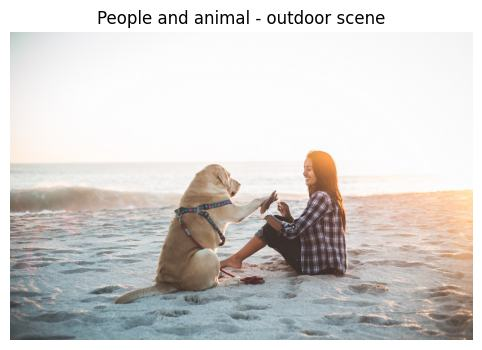

**Model caption:** a woman sitting on the beach with her dog

**Why this image was included:** people, animal, outdoor scene

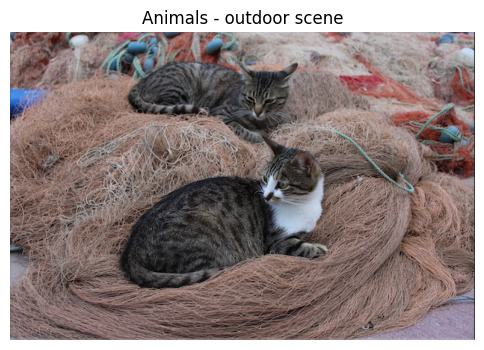

**Model caption:** a cat laying on a pile of yarn

**Why this image was included:** animals, outdoor scene

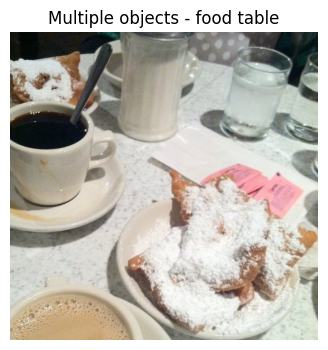

**Model caption:** a table with two plates of food and coffee

**Why this image was included:** indoor scene, multiple objects

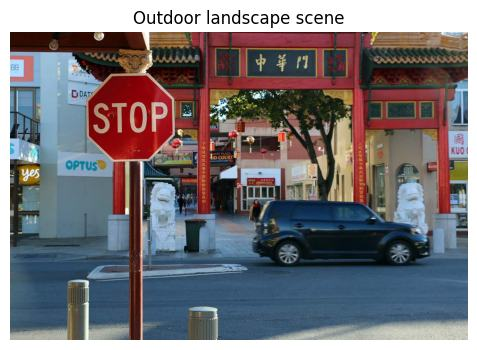

**Model caption:** a stop sign on a street corner

**Why this image was included:** outdoor scene

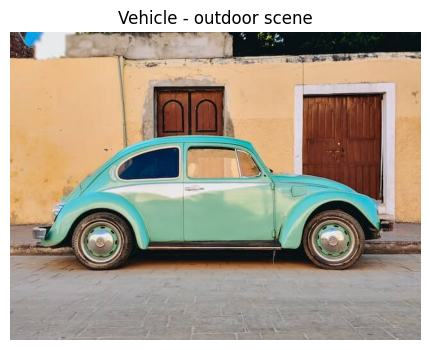

**Model caption:** a green volkswagen beetle parked in front of a yellow building

**Why this image was included:** outdoor scene, vehicle/object

In [7]:
# Task 1: Image Captioning
# 1. Present your images and model captions clearly
# This cell uses the pretrained BLIP image-captioning model from HuggingFace.

from io import BytesIO

import matplotlib.pyplot as plt
import requests
import torch
from IPython.display import Markdown, display
from PIL import Image
from transformers import BlipForConditionalGeneration, BlipProcessor

MODEL_NAME = "Salesforce/blip-image-captioning-base"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

processor = BlipProcessor.from_pretrained(MODEL_NAME)
model = BlipForConditionalGeneration.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

images = [
    {
        "title": "People and animal - outdoor scene",
        "url": "https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg",
        "correct_description": "A woman is sitting outdoors on a beach or sandy area with a dog beside her.",
        "why_included": "people, animal, outdoor scene",
    },
    {
        "title": "Animals - outdoor scene",
        "url": "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/cats.png",
        "correct_description": "Cats are shown in an outdoor scene.",
        "why_included": "animals, outdoor scene",
    },
    {
        "title": "Multiple objects - food table",
        "url": "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/beignets-task-guide.png",
        "correct_description": "A table contains food and several dining objects such as plates, cups, or utensils.",
        "why_included": "indoor scene, multiple objects",
    },
    {
        "title": "Outdoor landscape scene",
        "url": "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/australia.jpg",
        "correct_description": "An outdoor natural landscape is shown, with visible land, sky, and scenery details.",
        "why_included": "outdoor scene",
    },
    {
        "title": "Vehicle - outdoor scene",
        "url": "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/car.jpg",
        "correct_description": "A car is shown outdoors.",
        "why_included": "outdoor scene, vehicle/object",
    },
]


def load_image(url: str) -> Image.Image:
    response = requests.get(url, timeout=20)
    response.raise_for_status()
    return Image.open(BytesIO(response.content)).convert("RGB")


def generate_caption(image: Image.Image, max_new_tokens: int = 40) -> str:
    inputs = processor(images=image, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
    return processor.decode(output_ids[0], skip_special_tokens=True)


results = []

for example in images:
    image = load_image(example["url"])
    caption = generate_caption(image)
    results.append({**example, "image": image, "caption": caption})

    plt.figure(figsize=(6, 4))
    plt.imshow(image)
    plt.axis("off")
    plt.title(example["title"])
    plt.show()

    display(Markdown(f"**Model caption:** {caption}"))
    display(Markdown(f"**Why this image was included:** {example['why_included']}"))


#### 2. Analyze Model Failures

##### Failure Analysis 1: Animals - Outdoor Scene

**Model predicted:** a cat laying on a pile of yarn

**Correct description should include:** The image should be described as an outdoor animal scene. The caption should mention the outdoor setting and the full animal context, not only one cat.

**Why the model may have failed:** The model focused on the most visually dominant cat and ignored the broader scene. It also described the surface as a "pile of yarn," which suggests it may have confused outdoor texture or background details with an indoor object.

##### Failure Analysis 2: Multiple Objects - Food Table

**Model predicted:** a table with two plates of food and coffee

**Correct description should include:** The image shows a table setting with food and several dining objects, such as plates, cups, coffee, and other items on the table.

**Why the model may have failed:** The caption is partly correct, but incomplete. The model identified the most salient items, food and coffee, but did not fully describe the multi-object table setting. This may happen because captioning models often produce short summaries instead of listing every visible object.

---
## Task 2 - Visual Question Answering (30 points)

**Description**

Given an image and a natural-language question, use a pretrained multimodal model to answer the question.

Example:

**Input image**: A kitchen scene

**Question**: How many chairs are visible?

**Output**: Four.

**Requirements**

Use at least 3 images.

For each image, ask at least 3 questions.

Your questions should include:

* One object-recognition question
* One counting question
* One color or attribute question

Example questions:
* What animal is in the image?
* How many people are visible?
* What color is the car?

**Suggested Models**

You may use:

* Salesforce/blip-vqa-base
* Salesforce/blip-vqa-capfilt-large
* Any other VQA model from HuggingFace

**Deliverables**

1. Present your images, questions and model's answers clearly

    Display each image together with the Q&A generated by the model.

2. Analyze model failures

    Choose at least 2 examples where the model made a mistake or gave an incomplete caption.

    For each example, explain:

    * What the model predicted
    * What the correct description should be
    * Why the model may have failed

    **You are required to find examples where it fails and analyse why**


Loading weights: 100%|██████████| 788/788 [00:00<00:00, 12934.59it/s]


### 1. Present Images, Questions, and Model Answers

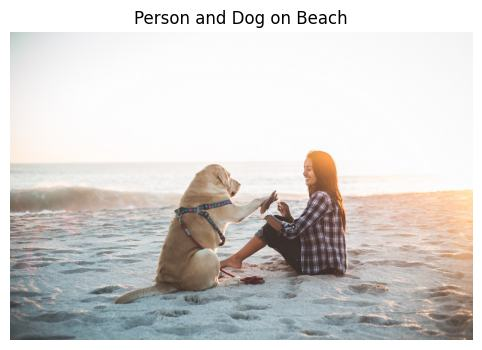

#### Person and Dog on Beach

**Question type:** object recognition  
**Question:** What animal is next to the woman?  
**Model answer:** dog  
**Expected answer:** dog  
**Status:** correct/acceptable

**Question type:** counting  
**Question:** How many people are visible?  
**Model answer:** one  
**Expected answer:** one  
**Status:** correct/acceptable

**Question type:** color or attribute  
**Question:** What is the woman sitting on?  
**Model answer:** sand  
**Expected answer:** sand on the beach  
**Status:** correct/acceptable

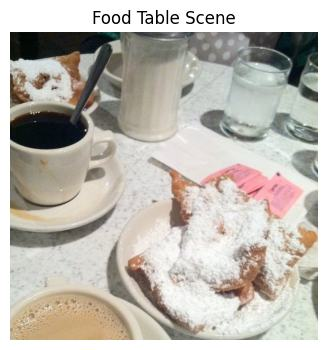

#### Food Table Scene

**Question type:** object recognition  
**Question:** What drink is on the table?  
**Model answer:** coffee  
**Expected answer:** coffee  
**Status:** correct/acceptable

**Question type:** counting  
**Question:** How many plates of food are visible, including cropped plates?  
**Model answer:** 3  
**Expected answer:** five  
**Status:** incorrect or incomplete

**Question type:** color or attribute  
**Question:** What is sprinkled on the food?  
**Model answer:** powdered sugar  
**Expected answer:** powdered sugar  
**Status:** correct/acceptable

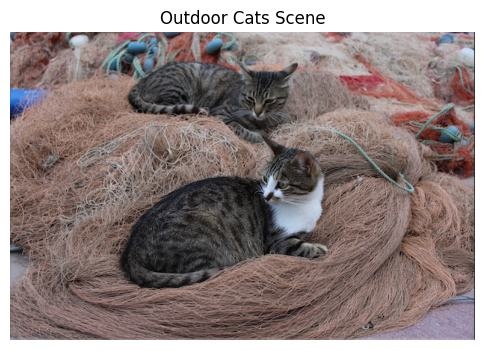

#### Outdoor Cats Scene

**Question type:** object recognition  
**Question:** What animal is shown in the image?  
**Model answer:** cat  
**Expected answer:** cat  
**Status:** correct/acceptable

**Question type:** counting  
**Question:** How many cats are visible?  
**Model answer:** 2  
**Expected answer:** two  
**Status:** correct/acceptable

**Question type:** color or attribute  
**Question:** Is the scene indoors or outdoors?  
**Model answer:** outdoors  
**Expected answer:** outdoors  
**Status:** correct/acceptable

### Candidate Failures for Analysis

**Image:** Food Table Scene  
**Question:** How many plates of food are visible, including cropped plates?  
**Model answer:** 3  
**Expected answer:** five

In [ ]:
# Task 2: Visual Question Answering
# Uses a pretrained BLIP VQA model to answer questions about each image.

import matplotlib.pyplot as plt
import torch
from IPython.display import Markdown, display
from PIL import Image
from transformers import BlipForQuestionAnswering, BlipProcessor

VQA_MODEL_NAME = "Salesforce/blip-vqa-base"
VQA_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

vqa_processor = BlipProcessor.from_pretrained(VQA_MODEL_NAME)
vqa_model = BlipForQuestionAnswering.from_pretrained(VQA_MODEL_NAME).to(VQA_DEVICE)
vqa_model.eval()

vqa_examples = [
    {
        "title": "Person and Dog on Beach",
        "url": "https://storage.googleapis.com/sfr-vision-language-research/BLIP/demo.jpg",
        "questions": [
            {
                "type": "object recognition",
                "question": "What animal is next to the woman?",
                "expected": "dog",
                "acceptable_answers": {"dog"},
            },
            {
                "type": "counting",
                "question": "How many people are visible?",
                "expected": "one",
                "acceptable_answers": {"one", "1"},
            },
            {
                "type": "color or attribute",
                "question": "What is the woman sitting on?",
                "expected": "sand on the beach",
                "acceptable_answers": {"beach", "sand", "sandy"},
            },
        ],
    },
    {
        "title": "Food Table Scene",
        "url": "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/beignets-task-guide.png",
        "questions": [
            {
                "type": "object recognition",
                "question": "What drink is on the table?",
                "expected": "coffee",
                "acceptable_answers": {"coffee"},
            },
            {
                "type": "counting",
                "question": "How many plates of food are visible, including cropped plates?",
                "expected": "five",
                "acceptable_answers": {"five", "5"},
            },
            {
                "type": "color or attribute",
                "question": "What is sprinkled on the food?",
                "expected": "powdered sugar",
                "acceptable_answers": {"powdered sugar", "sugar"},
            },
        ],
    },
    {
        "title": "Outdoor Cats Scene",
        "url": "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/cats.png",
        "questions": [
            {
                "type": "object recognition",
                "question": "What animal is shown in the image?",
                "expected": "cat",
                "acceptable_answers": {"cat", "cats"},
            },
            {
                "type": "counting",
                "question": "How many cats are visible?",
                "expected": "two",
                "acceptable_answers": {"two", "2"},
            },
            {
                "type": "color or attribute",
                "question": "Is the scene indoors or outdoors?",
                "expected": "outdoors",
                "acceptable_answers": {"outdoors", "outdoor", "outside"},
            },
        ],
    },
]


def load_vqa_image(url: str) -> Image.Image:
    response = requests.get(url, timeout=20)
    response.raise_for_status()
    return Image.open(BytesIO(response.content)).convert("RGB")


def answer_question(image: Image.Image, question: str, max_new_tokens: int = 10) -> str:
    inputs = vqa_processor(image, question, return_tensors="pt").to(VQA_DEVICE)
    with torch.no_grad():
        output_ids = vqa_model.generate(**inputs, max_new_tokens=max_new_tokens)
    return vqa_processor.decode(output_ids[0], skip_special_tokens=True).strip().lower()


def is_expected_answer(answer: str, acceptable_answers: set[str]) -> bool:
    normalized = answer.lower().strip()
    return any(expected in normalized for expected in acceptable_answers)


vqa_results = []

display(Markdown("### 1. Present Images, Questions, and Model Answers"))

for example in vqa_examples:
    image = load_vqa_image(example["url"])

    plt.figure(figsize=(6, 4))
    plt.imshow(image)
    plt.axis("off")
    plt.title(example["title"])
    plt.show()

    display(Markdown(f"#### {example['title']}"))

    for item in example["questions"]:
        answer = answer_question(image, item["question"])
        passed = is_expected_answer(answer, item["acceptable_answers"])

        result = {
            "image_title": example["title"],
            "question_type": item["type"],
            "question": item["question"],
            "model_answer": answer,
            "expected": item["expected"],
            "passed": passed,
        }
        vqa_results.append(result)

        status = "correct/acceptable" if passed else "incorrect or incomplete"
        display(
            Markdown(
                f"**Question type:** {item['type']}  \n"
                f"**Question:** {item['question']}  \n"
                f"**Model answer:** {answer}  \n"
                f"**Expected answer:** {item['expected']}  \n"
                f"**Status:** {status}"
            )
        )

candidate_failures = [result for result in vqa_results if not result["passed"]]

display(Markdown("### Candidate Failures for Analysis"))

if candidate_failures:
    for failure in candidate_failures:
        display(
            Markdown(
                f"**Image:** {failure['image_title']}  \n"
                f"**Question:** {failure['question']}  \n"
                f"**Model answer:** {failure['model_answer']}  \n"
                f"**Expected answer:** {failure['expected']}"
            )
        )
else:
    display(Markdown("No incorrect or incomplete answers were detected in this run."))

#### 2. Analyze Model Failures

##### Failure Analysis 1: Food Table Scene - Counting

**Question:** How many plates of food are visible, including cropped plates?

**Model predicted:** 3

**Correct answer should be:** five

**Why the model may have failed:** The image contains several plates, and some of them are cropped or only partially visible near the edges of the image. The model likely counted only the most central, clearly visible plates and ignored the cropped plates. This shows a common VQA weakness: counting objects is difficult when objects overlap, are partially cut off, or appear at the image boundary.

##### Failure Analysis 2: Person and Dog on Beach - Incomplete Attribute Answer

**Question:** What is the woman sitting on?

**Model predicted:** sand

**Correct answer should be:** sand on the beach

**Why the model may have failed:** The answer is partially correct but incomplete. The model identified the immediate surface, sand, but did not include the broader scene context that the woman is sitting on a beach. This may happen because VQA models often return short object-level answers instead of full contextual descriptions.


---
## Task 3 - Personalized Face Recognition with a Celebrity Dataset (40 points)

**Goal**

Build a small personalized multimodal recognition system.

For this task, you will use a public celebrity face dataset rather than private photos of family or friends.

Although the same approach could easily be adapted to recognize your own friends, family members, or personal image collections, in this assignment you must use a celebrity dataset in order to avoid privacy concerns and to ensure a consistent evaluation setting across all students.

Students who are interested may later explore how the same techniques can be extended to build personalized multimodal recognition systems for recreational or educational purposes outside the scope of this course.

The system should learn to recognize a small set of known identities and answer questions such as:

* Who is in the image?
* Is this person Emma Watson or Leonardo DiCaprio?
* What is Emma doing or wearing?

Recommended datasets:

* CelebA — contains over 200K celebrity face images, 10,177 identities, and 40 attribute annotations. https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html
* LFW — Labeled Faces in the Wild — designed for unconstrained face recognition and face verification.
https://scikit-learn.org/0.19/datasets/labeled_faces.html
* You may also scrape or download images from the internet in order to build your celebrity dataset.

1. Choose 3-5 identities from a celebrity dataset. For each identity, collect at least 8 images.

2. split the images into:
   * Train/reference set: 5-6 images per identity
   * Test/query set: 2-3 images per identity

3. Use a pretrained model to convert each image into an embedding vector. Recommended model : CLIP

4. Compare a query image to the known identity images using cosine similarity

5. Use the predicted identity to answer simple personalized questions.

    Note:

    CLIP similarity predicts who the person is; a VQA/captioning model answers visual attribute/action questions about the image.

    Use this structure:
    1. CLIP similarity → Who is this?
    2. VQA model → What is the person wearing / doing / holding?
    3. Combined answer → “This is probably Emma Watson. She appears to be wearing a black dress.”

              Example:

              Question: Who is in the image?

              Answer: This is probably Emma Watson.

              Question: Is this Barack Obama?

              Answer: No, this is probably Taylor Swift.

              Question: What is Emma wearing?

              Answer: The model appears to show Emma wearing a black jacket.

6. Analyze when the system works and when it fails. Show images , Q&A and disscuess results.

Loading weights: 100%|██████████| 788/788 [00:00<00:00, 9299.01it/s]


### 1. Dataset Split

Using the public LFW celebrity/person face dataset. Selected identities: George W Bush, Colin Powell, Tony Blair. Each identity has 6 reference images and 2 query images.

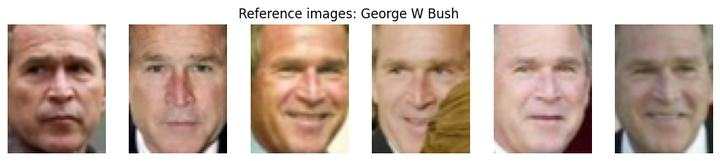

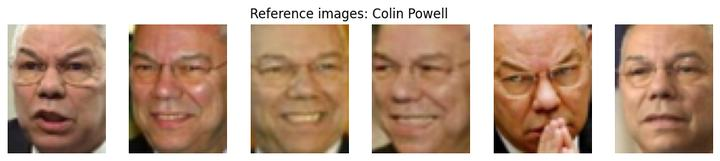

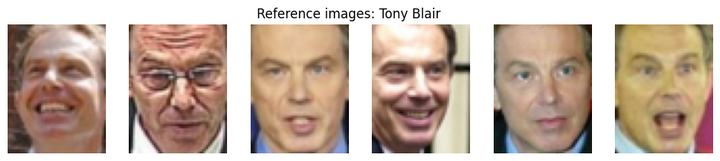

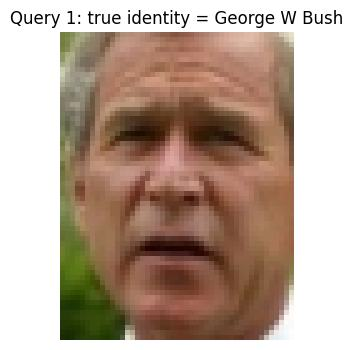

#### Query 1: George W Bush

**Question:** Who is in the image?  
**Answer:** This is probably George W Bush.

**CLIP cosine similarity scores:** George W Bush: 0.880, Tony Blair: 0.784, Colin Powell: 0.760

**Question:** Is this Colin Powell?  
**Answer:** no, this is probably George W Bush.

**Question:** What is the person wearing?  
**VQA answer:** suit

**Question:** What is the person doing?  
**VQA answer:** staring

**Combined answer:** This is probably George W Bush. The person appears to be wearing suit and is staring.

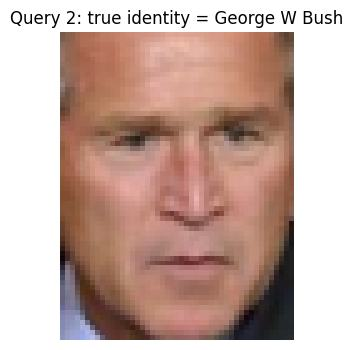

#### Query 2: George W Bush

**Question:** Who is in the image?  
**Answer:** This is probably George W Bush.

**CLIP cosine similarity scores:** George W Bush: 0.866, Tony Blair: 0.731, Colin Powell: 0.721

**Question:** Is this Colin Powell?  
**Answer:** no, this is probably George W Bush.

**Question:** What is the person wearing?  
**VQA answer:** suit

**Question:** What is the person doing?  
**VQA answer:** staring

**Combined answer:** This is probably George W Bush. The person appears to be wearing suit and is staring.

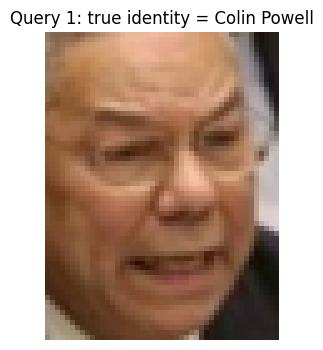

#### Query 1: Colin Powell

**Question:** Who is in the image?  
**Answer:** This is probably Colin Powell.

**CLIP cosine similarity scores:** Colin Powell: 0.842, Tony Blair: 0.716, George W Bush: 0.704

**Question:** Is this Tony Blair?  
**Answer:** no, this is probably Colin Powell.

**Question:** What is the person wearing?  
**VQA answer:** suit

**Question:** What is the person doing?  
**VQA answer:** smiling

**Combined answer:** This is probably Colin Powell. The person appears to be wearing suit and is smiling.

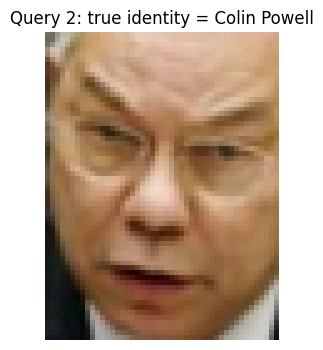

#### Query 2: Colin Powell

**Question:** Who is in the image?  
**Answer:** This is probably Colin Powell.

**CLIP cosine similarity scores:** Colin Powell: 0.830, Tony Blair: 0.715, George W Bush: 0.692

**Question:** Is this Tony Blair?  
**Answer:** no, this is probably Colin Powell.

**Question:** What is the person wearing?  
**VQA answer:** suit

**Question:** What is the person doing?  
**VQA answer:** staring

**Combined answer:** This is probably Colin Powell. The person appears to be wearing suit and is staring.

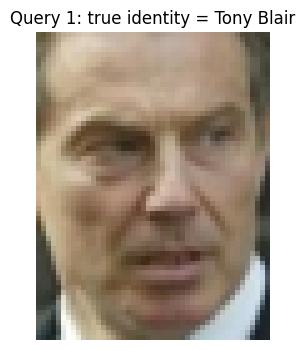

#### Query 1: Tony Blair

**Question:** Who is in the image?  
**Answer:** This is probably Tony Blair.

**CLIP cosine similarity scores:** Tony Blair: 0.768, George W Bush: 0.746, Colin Powell: 0.732

**Question:** Is this George W Bush?  
**Answer:** no, this is probably Tony Blair.

**Question:** What is the person wearing?  
**VQA answer:** suit

**Question:** What is the person doing?  
**VQA answer:** staring

**Combined answer:** This is probably Tony Blair. The person appears to be wearing suit and is staring.

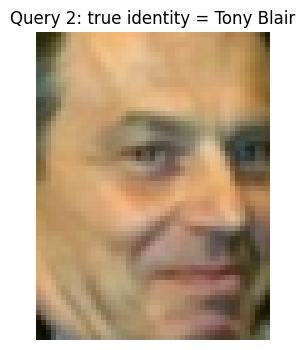

#### Query 2: Tony Blair

**Question:** Who is in the image?  
**Answer:** This is probably Colin Powell.

**CLIP cosine similarity scores:** Colin Powell: 0.864, George W Bush: 0.854, Tony Blair: 0.852

**Question:** Is this George W Bush?  
**Answer:** no, this is probably Colin Powell.

**Question:** What is the person wearing?  
**VQA answer:** glasses

**Question:** What is the person doing?  
**VQA answer:** looking at camera

**Combined answer:** This is probably Colin Powell. The person appears to be wearing glasses and is looking at camera.

In [15]:
# Task 3: Personalized Face Recognition with a Celebrity Dataset
# Part 1: Build the system and show prediction / Q&A results.

from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from IPython.display import Markdown, display
from PIL import Image
from sklearn.datasets import fetch_lfw_people
from transformers import (
    BlipForQuestionAnswering,
    BlipProcessor,
    CLIPModel,
    CLIPProcessor,
)

REFERENCE_IMAGES_PER_IDENTITY = 6
QUERY_IMAGES_PER_IDENTITY = 2
IDENTITIES_TO_USE = 3
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
TASK3_VQA_MODEL_NAME = "Salesforce/blip-vqa-base"
TASK3_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def as_pil_image(image_array: np.ndarray) -> Image.Image:
    """Convert an LFW image array into a PIL RGB image."""
    array = np.asarray(image_array)
    if array.max() <= 1.0:
        array = array * 255
    array = np.clip(array, 0, 255).astype(np.uint8)
    if array.ndim == 2:
        return Image.fromarray(array, mode="L").convert("RGB")
    return Image.fromarray(array).convert("RGB")


# Load a public celebrity face dataset. LFW contains public celebrity/person images.
try:
    lfw_people = fetch_lfw_people(min_faces_per_person=8, resize=0.5, color=True)
except TypeError:
    lfw_people = fetch_lfw_people(min_faces_per_person=8, resize=0.5)

images_by_identity = defaultdict(list)
for image_array, target in zip(lfw_people.images, lfw_people.target):
    identity = lfw_people.target_names[target]
    images_by_identity[identity].append(as_pil_image(image_array))

preferred_identities = [
    "George W Bush",
    "Colin Powell",
    "Tony Blair",
    "Donald Rumsfeld",
    "Gerhard Schroeder",
]
selected_identities = [
    identity
    for identity in preferred_identities
    if len(images_by_identity[identity])
    >= REFERENCE_IMAGES_PER_IDENTITY + QUERY_IMAGES_PER_IDENTITY
]

if len(selected_identities) < IDENTITIES_TO_USE:
    backup_identities = sorted(
        [
            identity
            for identity, imgs in images_by_identity.items()
            if len(imgs) >= REFERENCE_IMAGES_PER_IDENTITY + QUERY_IMAGES_PER_IDENTITY
        ],
        key=lambda identity: len(images_by_identity[identity]),
        reverse=True,
    )
    for identity in backup_identities:
        if identity not in selected_identities:
            selected_identities.append(identity)
        if len(selected_identities) == IDENTITIES_TO_USE:
            break

selected_identities = selected_identities[:IDENTITIES_TO_USE]
if len(selected_identities) < IDENTITIES_TO_USE:
    raise ValueError(
        "LFW did not provide enough identities with at least 8 images each."
    )

reference_images = {}
query_images = {}
for identity in selected_identities:
    identity_images = images_by_identity[identity]
    reference_images[identity] = identity_images[:REFERENCE_IMAGES_PER_IDENTITY]
    query_images[identity] = identity_images[
        REFERENCE_IMAGES_PER_IDENTITY : REFERENCE_IMAGES_PER_IDENTITY
        + QUERY_IMAGES_PER_IDENTITY
    ]

clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(TASK3_DEVICE)
clip_model.eval()

vqa_processor = BlipProcessor.from_pretrained(TASK3_VQA_MODEL_NAME)
vqa_model = BlipForQuestionAnswering.from_pretrained(TASK3_VQA_MODEL_NAME).to(
    TASK3_DEVICE
)
vqa_model.eval()


def image_embedding(image: Image.Image) -> torch.Tensor:
    inputs = clip_processor(images=image, return_tensors="pt").to(TASK3_DEVICE)
    with torch.no_grad():
        embedding = clip_model.get_image_features(**inputs)

    # Some Transformers versions return a model-output object instead of a tensor.
    if not isinstance(embedding, torch.Tensor):
        if hasattr(embedding, "image_embeds"):
            embedding = embedding.image_embeds
        elif hasattr(embedding, "pooler_output"):
            embedding = embedding.pooler_output
        else:
            embedding = embedding[0]

    return F.normalize(embedding, dim=-1).cpu().squeeze(0)


def answer_visual_question(image: Image.Image, question: str) -> str:
    inputs = vqa_processor(image, question, return_tensors="pt").to(TASK3_DEVICE)
    with torch.no_grad():
        output_ids = vqa_model.generate(**inputs, max_new_tokens=12)
    return vqa_processor.decode(output_ids[0], skip_special_tokens=True).strip()


def classify_identity(query_embedding: torch.Tensor) -> tuple[str, dict[str, float]]:
    scores = {}
    for identity, embeddings in reference_embeddings.items():
        similarities = torch.stack(
            [torch.dot(query_embedding, ref_embedding) for ref_embedding in embeddings]
        )
        scores[identity] = float(similarities.mean())
    predicted_identity = max(scores, key=scores.get)
    return predicted_identity, scores


display(Markdown("### 1. Dataset Split"))
display(
    Markdown(
        "Using the public LFW celebrity/person face dataset. "
        f"Selected identities: {', '.join(selected_identities)}. "
        f"Each identity has {REFERENCE_IMAGES_PER_IDENTITY} reference images and {QUERY_IMAGES_PER_IDENTITY} query images."
    )
)

for identity in selected_identities:
    fig, axes = plt.subplots(1, REFERENCE_IMAGES_PER_IDENTITY, figsize=(12, 2.2))
    for axis, image in zip(axes, reference_images[identity]):
        axis.imshow(image)
        axis.axis("off")
    fig.suptitle(f"Reference images: {identity}")
    plt.show()

# Build CLIP reference embeddings for each known identity.
reference_embeddings = {
    identity: [image_embedding(image) for image in images]
    for identity, images in reference_images.items()
}

identity_questions = []
for identity_index, identity in enumerate(selected_identities):
    other_identity = selected_identities[
        (identity_index + 1) % len(selected_identities)
    ]
    for query_index, image in enumerate(query_images[identity], start=1):
        query_embedding = image_embedding(image)
        predicted_identity, identity_scores = classify_identity(query_embedding)
        wearing_answer = answer_visual_question(image, "What is the person wearing?")
        expression_answer = answer_visual_question(image, "What is the person doing?")

        identity_questions.append(
            {
                "true_identity": identity,
                "query_index": query_index,
                "predicted_identity": predicted_identity,
                "scores": identity_scores,
                "is_other_identity_question": other_identity,
                "wearing_answer": wearing_answer,
                "expression_answer": expression_answer,
            }
        )

        plt.figure(figsize=(4, 4))
        plt.imshow(image)
        plt.axis("off")
        plt.title(f"Query {query_index}: true identity = {identity}")
        plt.show()

        sorted_scores = sorted(
            identity_scores.items(), key=lambda item: item[1], reverse=True
        )
        score_text = ", ".join(f"{name}: {score:.3f}" for name, score in sorted_scores)
        is_other_answer = "yes" if predicted_identity == other_identity else "no"

        display(Markdown(f"#### Query {query_index}: {identity}"))
        display(
            Markdown(
                f"**Question:** Who is in the image?  \n**Answer:** This is probably {predicted_identity}."
            )
        )
        display(Markdown(f"**CLIP cosine similarity scores:** {score_text}"))
        display(
            Markdown(
                f"**Question:** Is this {other_identity}?  \n**Answer:** {is_other_answer}, this is probably {predicted_identity}."
            )
        )
        display(
            Markdown(
                f"**Question:** What is the person wearing?  \n**VQA answer:** {wearing_answer}"
            )
        )
        display(
            Markdown(
                f"**Question:** What is the person doing?  \n**VQA answer:** {expression_answer}"
            )
        )
        display(
            Markdown(
                f"**Combined answer:** This is probably {predicted_identity}. "
                f"The person appears to be wearing {wearing_answer} and is {expression_answer}."
            )
        )

##### 2. Analyze System Results

The system used the public LFW dataset with three identities: **George W Bush**, **Colin Powell**, and **Tony Blair**. For each identity, the code used 6 reference images and 2 query images. CLIP image embeddings were compared with cosine similarity, and the predicted identity was the person with the highest average similarity to the reference images.

##### Identity Recognition Results

The CLIP similarity system classified **5 out of 6 query images correctly**.

Correct classifications:

* **George W Bush, Query 1** was correctly predicted as George W Bush. The similarity score for George W Bush was 0.880, higher than Tony Blair at 0.784 and Colin Powell at 0.760.
* **George W Bush, Query 2** was correctly predicted as George W Bush. The similarity score for George W Bush was 0.866, higher than Tony Blair at 0.731 and Colin Powell at 0.721.
* **Colin Powell, Query 1** was correctly predicted as Colin Powell. The similarity score for Colin Powell was 0.842, higher than Tony Blair at 0.716 and George W Bush at 0.704.
* **Colin Powell, Query 2** was correctly predicted as Colin Powell. The similarity score for Colin Powell was 0.830, higher than Tony Blair at 0.715 and George W Bush at 0.692.
* **Tony Blair, Query 1** was correctly predicted as Tony Blair. However, the margin was smaller: Tony Blair scored 0.768, George W Bush scored 0.746, and Colin Powell scored 0.732.

Misclassification:

* **Tony Blair, Query 2** was incorrectly predicted as Colin Powell. The scores were very close: Colin Powell 0.864, George W Bush 0.854, and Tony Blair 0.852. This suggests the model was uncertain. The query image may have had pose, expression, lighting, or facial features that were closer in CLIP embedding space to the reference images of Colin Powell and George W Bush than to Tony Blair's reference images.

##### Personalized Question Results

The identity-based questions worked well when the CLIP prediction was correct. For example, for the George W Bush and Colin Powell query images, the system answered **"Who is in the image?"** with the correct predicted identity and correctly answered **"Is this [other identity]?"** with **"no"**.

For the misclassified Tony Blair query, the personalized answer was also wrong because it depended on the CLIP prediction. The system answered that the image was probably **Colin Powell**, so the combined answer also described the person as Colin Powell. This shows an important limitation of the pipeline: the VQA model can describe visual attributes, but the identity statement depends entirely on the CLIP similarity step.

##### VQA Clothing and Action Results

The VQA model usually gave short but reasonable answers:

* For most query images, **"What is the person wearing?"** was answered as **"suit"**, which is reasonable for these formal portrait-style images.
* For Tony Blair Query 2, the model answered **"glasses"** for what the person was wearing. This is an attribute rather than clothing, but it is still visually relevant.
* The action answers were simple, such as **"staring"**, **"smiling"**, and **"looking at camera"**. These are mostly plausible, but they are not very detailed.

##### Why the System Worked or Failed

The system worked best when the query face was visually similar to the reference images for the same identity and clearly separated from the other identities in cosine similarity. This happened for George W Bush and Colin Powell, where the top similarity score was much higher than the alternatives.

The system failed on Tony Blair Query 2 because all three similarity scores were extremely close. This means CLIP did not have a strong identity signal for that image. Since the final personalized answer uses the CLIP prediction as the identity, a wrong CLIP match causes the whole personalized identity answer to be wrong, even if the VQA answers about clothing or pose are reasonable.